# TP53 - read counts modeling

In [15]:
# import required libraries
import pandas as pd
import numpy as np

import os
import pickle as pkl
import _pickle as cPickle
import re

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

## Loading data

In [50]:
# reading the df
mmrf_df=pd.read_csv("MMRF_CoMMpass_IA22_salmon_transcriptUnstrandedIgFiltered_counts.tsv", sep="\t", index_col=0)
mmrf_df.head()

,MMRF_1021_1_BM_CD138pos,MMRF_1024_1_BM_CD138pos,MMRF_1024_3_BM_CD138pos,MMRF_1024_2_BM_CD138pos,MMRF_1029_1_BM_CD138pos,MMRF_1030_1_BM_CD138pos,MMRF_1030_3_BM_CD138pos,MMRF_1030_4_BM_CD138pos,MMRF_1030_5_BM_CD138pos,MMRF_1031_1_BM_CD138pos,...,MMRF_2921_2_BM_CD138pos,MMRF_2924_1_BM_CD138pos,MMRF_2926_1_BM_CD138pos,MMRF_2936_1_PB_CD138pos,MMRF_2938_1_BM_CD138pos,MMRF_2939_1_BM_CD138pos,MMRF_2940_1_BM_CD138pos,MMRF_2941_1_BM_CD138pos,MMRF_2946_1_BM_CD138pos,MMRF_2947_1_BM_CD138pos
Transcript,,,,,,,,,,,,,,,,,,,,,
ENST00000000233,953.080,1481.820,1508.156,831.736,1384.857,693.857,874.605,3674.100,4526.460,860.448,...,2613.685,1223.449,1187.770,7156.645,1965.706,2782.523,3587.295,3614.036,2245.019,3032.207
ENST00000000412,4429.823,6050.341,6362.648,3754.320,10887.414,3934.778,5214.255,12300.601,5994.598,5334.391,...,16303.343,6170.538,3633.265,10975.095,11323.552,22478.751,16331.601,4057.584,17269.558,17270.860
ENST00000000442,600.068,2497.376,4562.165,2093.354,1843.254,2675.086,1681.132,3280.532,3352.618,1022.878,...,1670.557,740.718,1636.100,2158.735,2046.878,4077.976,13199.099,7505.208,4082.440,8434.376
ENST00000001008,2359.285,3770.100,2821.231,2147.167,2831.345,1611.774,4341.578,14503.645,9585.649,2131.782,...,7477.418,2304.555,1635.291,2738.629,8214.866,5775.432,4874.765,1278.660,7699.509,7051.009
ENST00000001146,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,57.000,0.000,1.141,0.000,0.000,0.000,0.000,0.000,0.000,24.000


In [51]:
mmrf_df.isnull().values.any()

False

In [54]:
# loading TP isoforms df
tp53_df=pd.read_csv("tp53_isoforms.tsv", sep="\t", index_col=0)
tp53_df

,isoform,ensembl_ID
0,p53alpha,ENST00000269305
1,p53beta,ENST00000420246
2,p53gamma,ENST00000455263
3,delta40p53alpha,ENST00000619485
4,delta40p53beta,ENST00000622645
5,delta133p53alpha,ENST00000504937
6,delta160p53alpha,ENST00000619186
7,delta133p53beta,ENST00000510385


In [63]:
#filtering mmrf_df based on tp53 isoforms
mmrf_df=mmrf_df.loc[mmrf_df.index.isin(tp53_df.ensembl_ID)]
mmrf_df

,MMRF_1021_1_BM_CD138pos,MMRF_1024_1_BM_CD138pos,MMRF_1024_3_BM_CD138pos,MMRF_1024_2_BM_CD138pos,MMRF_1029_1_BM_CD138pos,MMRF_1030_1_BM_CD138pos,MMRF_1030_3_BM_CD138pos,MMRF_1030_4_BM_CD138pos,MMRF_1030_5_BM_CD138pos,MMRF_1031_1_BM_CD138pos,...,MMRF_2921_2_BM_CD138pos,MMRF_2924_1_BM_CD138pos,MMRF_2926_1_BM_CD138pos,MMRF_2936_1_PB_CD138pos,MMRF_2938_1_BM_CD138pos,MMRF_2939_1_BM_CD138pos,MMRF_2940_1_BM_CD138pos,MMRF_2941_1_BM_CD138pos,MMRF_2946_1_BM_CD138pos,MMRF_2947_1_BM_CD138pos
Transcript,,,,,,,,,,,,,,,,,,,,,
ENST00000269305,596.129,2349.101,2380.068,1409.214,2002.701,1244.701,3278.659,4718.687,1103.093,2330.068,...,3630.624,64.343,612.970,12494.432,3138.669,4422.630,345.896,193.046,4364.360,4890.428
ENST00000420246,397.856,108.809,321.993,146.308,517.376,194.796,425.903,737.214,840.814,200.061,...,1476.522,342.058,205.344,1566.328,1212.534,276.959,3749.292,1376.038,1728.157,2653.986
ENST00000455263,0.000,0.000,26.617,14.190,0.000,0.000,34.640,0.000,41.532,0.000,...,169.270,0.000,0.000,170.441,141.578,24.904,128.662,0.000,128.374,117.789
ENST00000504937,0.000,0.000,76.922,30.699,15.719,14.920,49.747,80.740,86.804,11.436,...,232.934,256.688,14.422,179.088,258.592,71.459,750.440,178.447,106.209,307.427
ENST00000510385,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [85]:
#filtering mmrf_df based on replicate number (taking only replicate 1)
mmrf_df=mmrf_df.loc[:, mmrf_df.columns.str.contains('.*_1_BM.*')]
mmrf_df

,MMRF_1021_1_BM_CD138pos,MMRF_1024_1_BM_CD138pos,MMRF_1029_1_BM_CD138pos,MMRF_1030_1_BM_CD138pos,MMRF_1031_1_BM_CD138pos,MMRF_1032_1_BM_CD138pos,MMRF_1033_1_BM_CD138pos,MMRF_1037_1_BM_CD138pos,MMRF_1038_1_BM_CD138pos,MMRF_1048_1_BM_CD138pos,...,MMRF_2914_1_BM_CD138pos,MMRF_2921_1_BM_CD138pos,MMRF_2924_1_BM_CD138pos,MMRF_2926_1_BM_CD138pos,MMRF_2938_1_BM_CD138pos,MMRF_2939_1_BM_CD138pos,MMRF_2940_1_BM_CD138pos,MMRF_2941_1_BM_CD138pos,MMRF_2946_1_BM_CD138pos,MMRF_2947_1_BM_CD138pos
Transcript,,,,,,,,,,,,,,,,,,,,,
ENST00000269305,596.129,2349.101,2002.701,1244.701,2330.068,603.088,1209.907,2675.892,1685.663,818.630,...,530.518,2551.661,64.343,612.970,3138.669,4422.630,345.896,193.046,4364.360,4890.428
ENST00000420246,397.856,108.809,517.376,194.796,200.061,335.121,690.894,564.847,241.843,577.598,...,597.222,829.714,342.058,205.344,1212.534,276.959,3749.292,1376.038,1728.157,2653.986
ENST00000455263,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,84.427,0.000,0.000,0.000,141.578,24.904,128.662,0.000,128.374,117.789
ENST00000504937,0.000,0.000,15.719,14.920,11.436,6.308,0.000,5.646,5.832,17.713,...,115.715,120.599,256.688,14.422,258.592,71.459,750.440,178.447,106.209,307.427
ENST00000510385,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [133]:
#removing suffix from cols name
cols=mmrf_df.columns.str.split("_1_[PBM]+_CD138pos$").str.join("").unique()
mmrf_df.columns=cols
mmrf_df.head()

IDs,MMRF_1021,MMRF_1024,MMRF_1029,MMRF_1030,MMRF_1031,MMRF_1032,MMRF_1033,MMRF_1037,MMRF_1038,MMRF_1048,...,MMRF_2914,MMRF_2921,MMRF_2924,MMRF_2926,MMRF_2938,MMRF_2939,MMRF_2940,MMRF_2941,MMRF_2946,MMRF_2947
Transcript,,,,,,,,,,,,,,,,,,,,,
ENST00000269305,596.129,2349.101,2002.701,1244.701,2330.068,603.088,1209.907,2675.892,1685.663,818.630,...,530.518,2551.661,64.343,612.970,3138.669,4422.630,345.896,193.046,4364.360,4890.428
ENST00000420246,397.856,108.809,517.376,194.796,200.061,335.121,690.894,564.847,241.843,577.598,...,597.222,829.714,342.058,205.344,1212.534,276.959,3749.292,1376.038,1728.157,2653.986
ENST00000455263,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,84.427,0.000,0.000,0.000,141.578,24.904,128.662,0.000,128.374,117.789
ENST00000504937,0.000,0.000,15.719,14.920,11.436,6.308,0.000,5.646,5.832,17.713,...,115.715,120.599,256.688,14.422,258.592,71.459,750.440,178.447,106.209,307.427
ENST00000510385,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [134]:
#rounding
mmrf_t_df=mmrf_df.transpose().round(0).astype("int64")
mmrf_t_df.index.name="IDs"
mmrf_t_df.head()

Transcript,ENST00000269305,ENST00000420246,ENST00000455263,ENST00000504937,ENST00000510385
IDs,,,,,
MMRF_1021,596,398,0,0,0
MMRF_1024,2349,109,0,0,0
MMRF_1029,2003,517,0,16,0
MMRF_1030,1245,195,0,15,0
MMRF_1031,2330,200,0,11,0


In [145]:
#loading clinical data
md_clinical_df=pd.read_csv("mmrf_clinical_data.tsv", sep="\t", index_col=0)
md_clinical_df.head()

,PUBLIC_ID,D_PT_age,D_PT_gender,D_PT_iss,VJ_INTERVAL,SS_HYPERCALCEMIA,SS_RENALINSUFFIC,SS_ANEMIAHEMOGLO,SS_BONELESIONSLY,ST_PLASMACYTOMAN,IC_INVOLVEDFREEL,D_LAB_serum_m_protein,D_LAB_urine_24hr_m_protein,line,thername,therstdy,therendy
0,MMRF_1014,64,2,1.0,Baseline,NaN,NaN,NaN,NaN,NaN,NaN,2.2,NaN,1,Bortezomib/Dexamethasone + Bortezomib/Lenalido...,1,1157
1,MMRF_1017,75,1,1.0,Baseline,NaN,NaN,NaN,checked,NaN,NaN,2.2,NaN,1,Lenalidomide/Dexamethasone,1,508
2,MMRF_1024,79,2,2.0,Baseline,NaN,checked,checked,NaN,NaN,NaN,2.6,0.000,1,Thalidomide/Melphalan/Prednisone + Lenalidomid...,1,582
3,MMRF_1038,69,1,3.0,Baseline,checked,NaN,NaN,checked,NaN,NaN,3.9,0.018,1,Lenalidomide/Dexamethasone,1,1738
4,MMRF_1033,64,1,1.0,Baseline,NaN,NaN,NaN,NaN,NaN,NaN,2.9,1.426,1,Lenalidomide/Dexamethasone,1,123


In [158]:
#filtering out those PUBLIC ID which do not have RNA data
mmrf_t_df.loc[mmrf_t_df.index.isin(md_clinical_df.PUBLIC_ID)].to_csv("mmrf_tp53_filtered.tsv", sep="\t")

In [157]:
#filtering clinical metadata based on those IDs present in mmrf_df
md_clinical_df.loc[md_clinical_df.PUBLIC_ID.isin(mmrf_t_df.index)].to_csv("test.tsv", sep="\t")

In [89]:
from google.colab import files
files.download("dds.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [90]:
from google.colab import files
files.download("ds.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
from google.colab import files
files.download("ds_lfc_shrink.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Transcripts normalization

### Applying DeSeq2 normalization
To perform DeSeq2's normalization procedure, we first need to create a DeseqDataSet obj from the count data.

In [92]:
inf=DefaultInference(n_cpus=8)

In [95]:
dds=DeseqDataSet(counts=mmrf_t_df, metadata=md_clinical_df, design="~VJ_INTERVAL",refit_cooks=True, inference=inf)

ValueError: Observations annot. `obs` must have as many rows as `X` has rows (767), but has 1172 rows.

In [22]:
#applying normalization
dds.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 5.33 seconds.

Fitting dispersions...
... done in 150.00 seconds.

Fitting dispersion trend curve...
... done in 19.82 seconds.

Fitting MAP dispersions...
... done in 172.74 seconds.

Fitting LFCs...
... done in 113.68 seconds.

Calculating cook's distance...
... done in 20.49 seconds.

Replacing 21274 outlier genes.

Fitting dispersions...
... done in 15.74 seconds.

Fitting MAP dispersions...
... done in 15.80 seconds.

Fitting LFCs...
... done in 18.43 seconds.



In [23]:
print(dds)

AnnData object with n_obs × n_vars = 933 × 224779
    obs: 'rep'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'


In [24]:
#saving dds annotated data ad pkl obj
with open("dds.pkl", "wb") as f:
  pkl.dump(dds, f)

In [25]:
print(dds.varm["dispersions"])

[2.22455906e-01 1.63813946e-01 3.74309220e-01 ... 3.21611857e+01
 4.97421995e-01 9.33000000e+02]


In [32]:
print(dds.varm["LFC"])

                 Intercept       rep
Transcript                          
ENST00000000233   7.302121  0.061538
ENST00000000412   8.480541  0.044144
ENST00000000442   7.626449 -0.052147
ENST00000001008   7.752645  0.127214
ENST00000001146   1.145931  0.014354
...                    ...       ...
ENST00000673604  -0.622853 -0.162862
ENST00000673615  -1.181360 -0.184480
ENST00000673617  -1.389455 -0.131834
ENST00000673620   5.693506 -0.153690
ENST00000673621  -0.608627 -0.403201

[224779 rows x 2 columns]


### Statistical analysis with PyDeseq2
Once dispersions and LFCs are fitted, p-values are computes and adjusted for differntial expression.
`DeseqStats` also takes as optional parameters the following ones:

- `alpha`: p-value and adjusted p-values significance threshold ($0.05$ by default);
- `cook_filtes`: whether to filter p-values based on cooks outliers (`True` by default);
- `independent_filter`: whether to perform independent filtering to correct p-value trends (`True` by default).

In [42]:
ds=DeseqStats(dds, contrast=["rep", 1, 2], inference=inf)

In [43]:
ds.summary()

Running Wald tests...
... done in 20.83 seconds.



Log2 fold change & Wald test p-value: rep 1 vs 2
                    baseMean  log2FoldChange     lfcSE      stat  \
Transcript                                                         
ENST00000000233  1606.581299       -0.088780  0.030355 -2.924754   
ENST00000000412  5102.731644       -0.063687  0.026033 -2.446358   
ENST00000000442  1920.805548        0.075232  0.039360  1.911391   
ENST00000001008  2751.568799       -0.183531  0.029683 -6.183031   
ENST00000001146     3.204153       -0.020709  0.277390 -0.074657   
...                      ...             ...       ...       ...   
ENST00000673604     0.415132        0.234960  0.370884  0.633514   
ENST00000673615     0.137618        0.266148  0.367571  0.724072   
ENST00000673617     0.072509        0.190196  0.393328  0.483556   
ENST00000673620   245.386467        0.221728  0.045565  4.866190   
ENST00000673621     0.389282        0.581696  1.971183  0.295100   

                       pvalue          padj  
Transcript          

In [44]:
# saving LFC shrinken as pkl obj
with open("ds.pkl", "wb") as f:
  pkl.dump(ds, f)

`plotMA()`: a scatter plot of $log2$ fold change (y-axis) vs the mean of normalized count (x-axis).

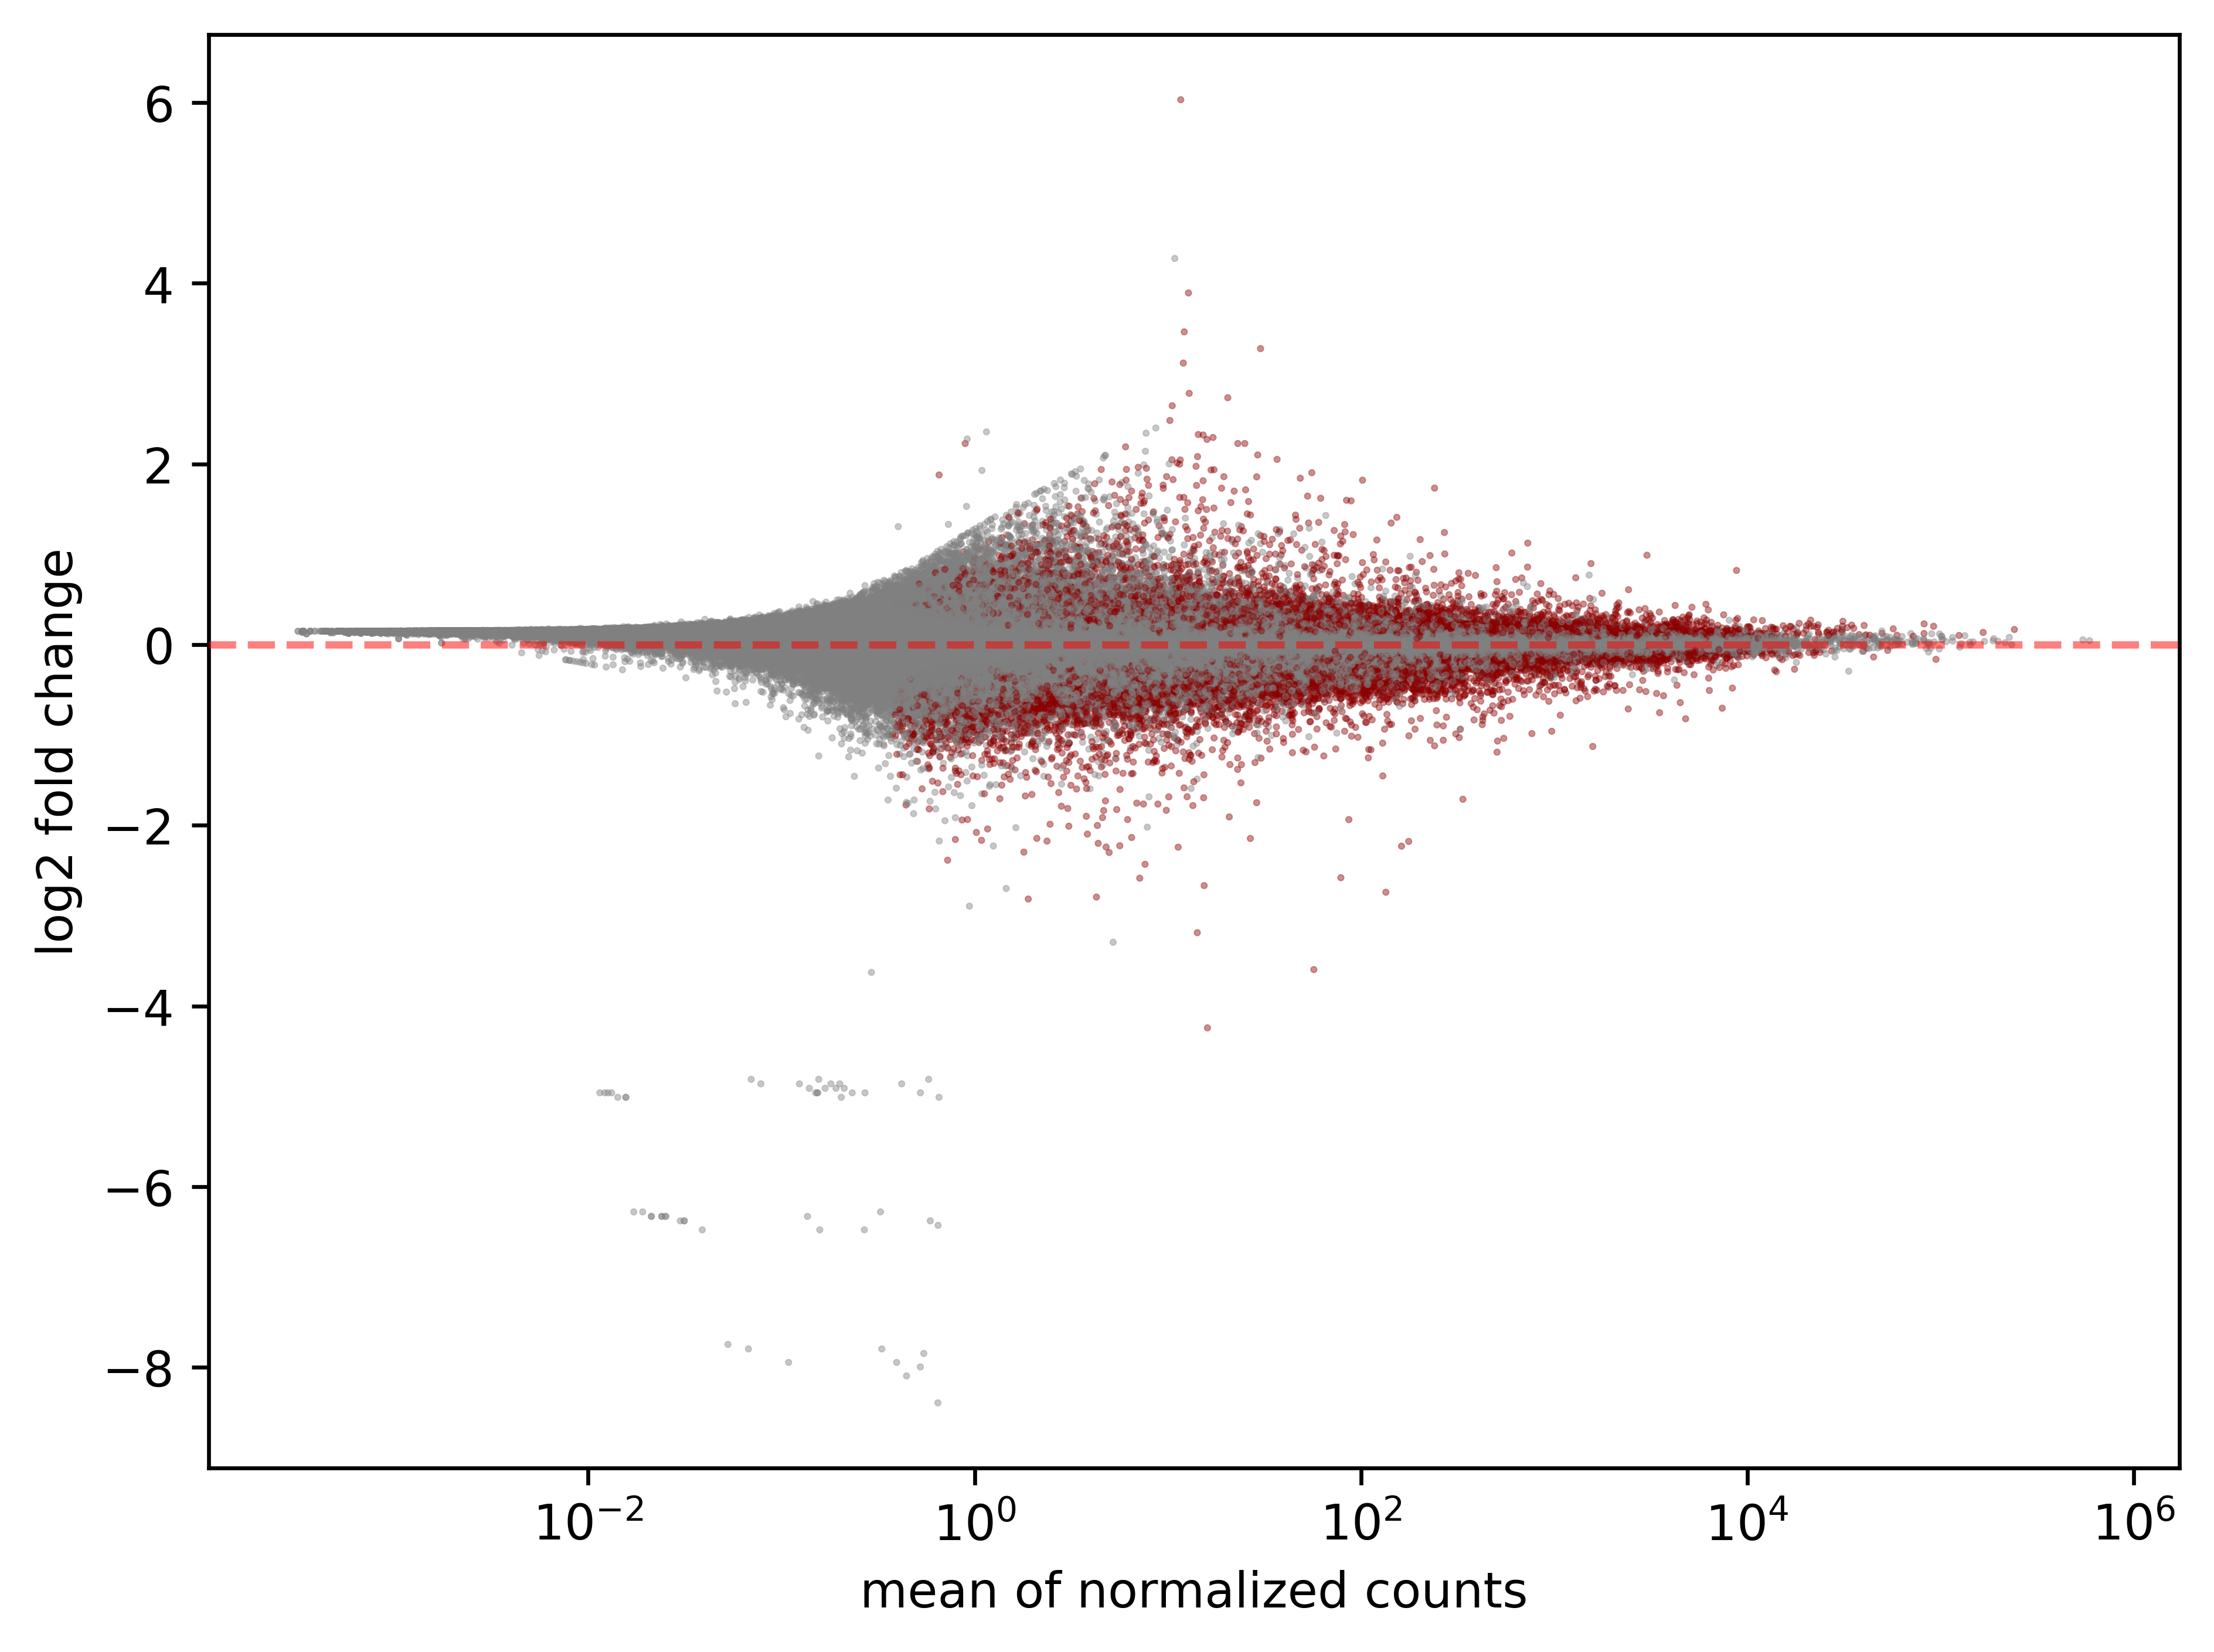

In [45]:
ds.plot_MA()

For visualization and post-processing purposes, it is adviced to proceed with LFC shrinkage.

In [46]:
ds.lfc_shrink(coeff="rep")

Fitting MAP LFCs...
... done in 156.50 seconds.



Shrunk log2 fold change & Wald test p-value: rep
                    baseMean  log2FoldChange     lfcSE      stat  \
Transcript                                                         
ENST00000000233  1606.581299        0.080443  0.031158 -2.924754   
ENST00000000412  5102.731644        0.058348  0.026361 -2.446358   
ENST00000000442  1920.805548       -0.062958  0.040375  1.911391   
ENST00000001008  2751.568799        0.176379  0.030008 -6.183031   
ENST00000001146     3.204153       -0.008943  0.178373 -0.074657   
...                      ...             ...       ...       ...   
ENST00000673604     0.415132       -0.005546  0.180455  0.633514   
ENST00000673615     0.137618       -0.026070  0.296901  0.724072   
ENST00000673617     0.072509       -0.012754  0.195139  0.483556   
ENST00000673620   245.386467       -0.205956  0.045605  4.866190   
ENST00000673621     0.389282       -0.001156  6.065932  0.295100   

                       pvalue          padj  
Transcript          

In [47]:
#saving shrinked-LFC as pkl obj
with open("ds_lfc_shrink.pkl", "wb") as f:
  pkl.dump(ds, f)